In [64]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/DigikalaProject"
)
comment_path = PROJECT_ROOT / "raw" /"comments_raw.parquet"

In [12]:
comments = pd.read_parquet(comment_path)

In [13]:
comments.shape

(6156289, 15)

In [14]:
comments.head()

,id,title,body,created_at,rate,recommendation_status,is_buyer,product_id,advantages,disadvantages,likes,dislikes,seller_title,seller_code,true_to_size_rate
0,53672599,پیشنهاد نمیشود,به درد نمیخوره,23 شهریور 1402,1.0,not_recommended,True,252058,<NA>,<NA>,0,0,دیجی‌کالا,5A52N,<NA>
1,9897229,بسته بندی بد,می‌تونست به عنوان یه کالای فرهنگی بهتر بسته بن...,16 تیر 1399,0.0,recommended,True,252058,['تجربه جالبی بود برام '],['بسته بندی جالبی نداشت'],1,0,دیجی‌کالا,5A52N,<NA>
2,38074516,برس ریمل,بسته بندیش خوب بود کاربرد و کیفیتشم خیلی خوب...,26 مرداد 1401,0.0,recommended,True,3331597,<NA>,<NA>,0,0,آرالیا بیوتی,ADM47,<NA>
3,18628562,خوبه و خوشرنگ,به نظرم خوبه فقط یکم ظریفه. از رنگش خوشم اومد ...,28 اسفند 1399,0.0,recommended,True,3331329,<NA>,<NA>,0,0,اینجاست آ,9ZMCZ,<NA>
4,53301258,برس رنگ مو,معمولیه اگه واسه خونه رنگ کردن شخصی میخواین او...,12 شهریور 1402,3.0,recommended,True,3255700,<NA>,<NA>,0,0,گالری آرایشی به سیما,CDWHA,<NA>


In [15]:
comments.columns

Index(['id', 'title', 'body', 'created_at', 'rate', 'recommendation_status',
       'is_buyer', 'product_id', 'advantages', 'disadvantages', 'likes',
       'dislikes', 'seller_title', 'seller_code', 'true_to_size_rate'],
      dtype='object')

In [16]:
comments['recommendation_status'].value_counts()

,count
recommendation_status,
recommended,4162839
no_idea,594121
not_recommended,504903


In [19]:
comments["recommendation_status"].value_counts(normalize=True) * 100

,proportion
recommendation_status,
recommended,79.113405
no_idea,11.291077
not_recommended,9.595518


In [17]:
df = comments[
    [
        "id",
        "product_id",
        "title",
        "body",
        "advantages",
        "disadvantages",
        "recommendation_status"
    ]
].copy()

In [22]:
df.isnull().sum()/df.shape[0]*100

,0
id,0.000000
product_id,0.000000
title,46.538783
body,0.010347
advantages,88.496235
disadvantages,93.303238
recommendation_status,14.528655
text,0.000000


In [23]:
df = df.dropna(
    subset=["recommendation_status"]
)

df.shape

(5261863, 8)

In [24]:
text_columns = [
    "title",
    "body",
    "advantages",
    "disadvantages"
]

for col in text_columns:
    df[col] = df[col].fillna("")


df["text"] = (
    df["title"]
    + " "
    + df["body"]
    + " "
    + df["advantages"]
    + " "
    + df["disadvantages"]
)

In [25]:
df[["text", "recommendation_status"]].sample(5)

,text,recommendation_status
3988489,زیاد مطمئن نیستم روش نوشته مخصوص پوستهای چرب....,no_idea
5210890,راستش بوی نفتش اون قدر زیاد بود گذاشتم توی ای...,not_recommended
2646444,خوب نبود با ده دقیقه پوشیدن پاره شد. قشنگ مث ت...,not_recommended
5672457,خیلی خوبه خوب بود اما وقتی باهاش بازی کردم حبا...,recommended
2933229,رنگ خوبیه رنگ ویتامول واقعا رنگ خوبیه فقط تناژ...,recommended


In [26]:
(df["text"].str.strip() == "").sum()

np.int64(10)

In [27]:
df = df[
    df["text"].str.strip() != ""
].copy()

df.shape

(5261853, 8)

In [28]:
df["product_id"].nunique()

309257

In [30]:
splitter = GroupShuffleSplit(
    test_size=0.2,
    random_state=42
)


train_idx, test_idx = next(
    splitter.split(
        df,
        groups=df["product_id"]
    )
)


train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

In [31]:
print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (4203084, 8)
Test: (1058769, 8)


In [32]:
train_products = set(train_df["product_id"])
test_products = set(test_df["product_id"])

overlap = train_products.intersection(test_products)

len(overlap)

0

In [33]:
print("Train distribution:")
print(
    train_df["recommendation_status"]
    .value_counts(normalize=True)
)


print("\nTest distribution:")
print(
    test_df["recommendation_status"]
    .value_counts(normalize=True)
)

Train distribution:
recommendation_status
recommended        0.791438
no_idea            0.112829
not_recommended    0.095733
Name: proportion, dtype: Float64

Test distribution:
recommendation_status
recommended        0.789929
no_idea            0.113233
not_recommended    0.096838
Name: proportion, dtype: Float64


Due to the large dataset size, a representative training subset was used for baseline experiments.

In [45]:
baseline_df = (
    train_df
    .sample(
        n=500000,
        random_state=42
    )
    .copy()
)

In [46]:
test_sample = (
    test_df
    .sample(
        n=100000,
        random_state=42
    )
    .copy()
)

In [35]:
baseline_df["recommendation_status"].value_counts(normalize=True)

,proportion
recommendation_status,
recommended,0.792232
no_idea,0.112256
not_recommended,0.095512


In [47]:
X_train_text = baseline_df["text"]

y_train = baseline_df["recommendation_status"]


X_test_text = test_sample["text"]

y_test = test_sample["recommendation_status"]

In [48]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2)
)

In [49]:
X_train = tfidf.fit_transform(
    X_train_text
)

In [50]:
X_test = tfidf.transform(
    X_test_text
)

In [51]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (500000, 50000)
Test shape: (100000, 50000)


In [52]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

In [53]:
model.fit(
    X_train,
    y_train
)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [54]:
y_pred = model.predict(
    X_test
)

In [55]:
macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

print(
    f"Macro F1: {macro_f1:.4f}"
)

Macro F1: 0.6833


In [56]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

                 precision    recall  f1-score   support

        no_idea       0.35      0.59      0.44     11286
not_recommended       0.66      0.77      0.71      9804
    recommended       0.96      0.85      0.90     78910

       accuracy                           0.81    100000
      macro avg       0.66      0.74      0.68    100000
   weighted avg       0.86      0.81      0.83    100000



In [62]:
cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[ 6706,  2347,  2233],
       [ 1909,  7542,   353],
       [10640,  1538, 66732]])

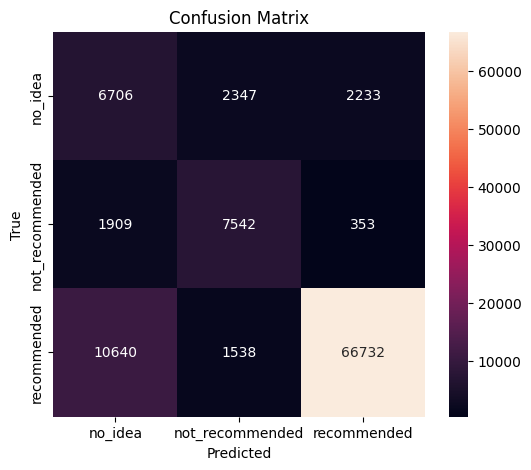

In [65]:

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()